# Mision 3: Voz del Cliente en las Reviews

Este notebook clasifica el sentimiento de las reviews de Olist como positivo o
negativo, usando NLP. Se comparan dos modelos: Naive Bayes (Multinomial) y SVM.

Target: construido a partir de review_score, no existe una columna de sentimiento
directa.
- Positivo: review_score 4 o 5
- Negativo: review_score 1 o 2
- Neutral (3 estrellas): descartado del entrenamiento, zona ambigua que no
  aporta señal clara a una clasificacion binaria

Solo se usan reviews con texto real (review_comment_message no nulo).

Tabla usada: order_reviews.

In [1]:
# pandas, numpy, matplotlib, seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# re: expresiones regulares para limpiar texto
import re
# Path
from pathlib import Path
# train_test_split y cross_val_score
from sklearn.model_selection import train_test_split, cross_val_score
# TF-IDF: vectorizacion de texto
from sklearn.feature_extraction.text import TfidfVectorizer
# MultinomialNB (clasico) y ComplementNB (variante)
from sklearn.naive_bayes import MultinomialNB, ComplementNB
# LinearSVC (lineal) y SVC (general)
from sklearn.svm import LinearSVC, SVC
# Pipeline: cadena vectorizador + clasificador
from sklearn.pipeline import Pipeline
# metricas de clasificacion
from sklearn.metrics import classification_report, confusion_matrix

# Silenciar warnings
import warnings
warnings.filterwarnings('ignore')
# Estilo de graficos
plt.style.use('seaborn-v0_8-whitegrid')

# data_raw: ruta
data_raw = Path("..") / "data" / "raw"

# reviews: resenas con score y texto
reviews = pd.read_csv(data_raw / "olist_order_reviews_dataset.csv")

## Reviews con texto y etiqueta de sentimiento

Quedarse solo con reviews que tienen review_comment_message real (no nulo),
descartar las de 3 estrellas, y binarizar review_score en sentimiento
positivo/negativo.

In [2]:
# Solo columnas utiles: score y comentario
reviews_text = reviews[['review_score', 'review_comment_message']].copy()
# Descarta las que no tienen texto
reviews_text = reviews_text.dropna(subset=['review_comment_message'])
# Descarta texto vacio (solo espacios)
reviews_text = reviews_text[reviews_text['review_comment_message'].str.strip() != '']
# Descarta las 3 estrellas (zona ambigua)
reviews_text = reviews_text[reviews_text['review_score'] != 3]

# Sentimiento: >=4 positivo, resto negativo
reviews_text['sentiment'] = np.where(reviews_text['review_score'] >= 4, 'positivo', 'negativo')

# Cabecera
print('Distribucion de sentimientos:')
# Conteo por clase
print(reviews_text['sentiment'].value_counts())
# Total final
print(f'\nTotal resenas con texto (sin 3 estrellas): {len(reviews_text)}')

Distribucion de sentimientos:
sentiment
positivo    26505
negativo    10889
Name: count, dtype: int64

Total resenas con texto (sin 3 estrellas): 37394


## Normalizacion del texto

Funcion de preprocesamiento para las reviews: minusculas, sacar urls y saltos de
linea, sacar contenidos que no sean letras (conservando tildes), y aplicar
stemming con RSLPStemmer para reducir variantes de una misma raiz. Las negaciones
se manejan aparte para no invertir el sentido de frases como "nao gostei".

In [3]:
# Stemmer para portugues (RSLP)
from nltk.stem import RSLPStemmer
# Stopwords en portugues
from nltk.corpus import stopwords

# set de stopwords
stop_pt = set(stopwords.words('portuguese'))
# Negaciones explicitas que se conservan
negaciones = {'nao', 'não', 'nem', 'nunca', 'jamais', 'nenhum', 'nenhuma', 'tampouco'}
# Resta negaciones de las stopwords (no se filtran)
stop_sin_negaciones = stop_pt - negaciones

# Instancia el stemmer
stemmer = RSLPStemmer()

# Funcion de limpieza
def limpiar_texto(texto):
# Minusculas
    texto = str(texto).lower()
# Quita URLs y saltos de linea
    texto = re.sub(r'http\S+|\n', ' ', texto)
# Quita menciones de dinero (R$ 90.00)
    texto = re.sub(r'r\$\s?\d+[\.,]?\d*', ' ', texto)
# Conserva solo letras (con acentos a-z + latin)
    texto = re.sub(r'[^a-zà-ÿ]', ' ', texto)
# Filtra stopwords (menos negaciones)
    palabras = [p for p in texto.split() if p not in stop_sin_negaciones]
# Aplica stemming y descarta palabras <= 2 letras
    palabras = [stemmer.stem(p) for p in palabras if len(p) > 2]
# Devuelve el texto limpio
    return ' '.join(palabras)

# Aplica la limpieza a toda la columna
reviews_text['texto_limpio'] = reviews_text['review_comment_message'].apply(limpiar_texto)
# Descarta textos que quedaron vacios
reviews_text = reviews_text[reviews_text['texto_limpio'].str.len() > 0]

# Cuantas reviews quedan
print(f'Reviews tras limpieza: {len(reviews_text)}')
# Comparacion antes/despues de limpiar
reviews_text[['review_comment_message', 'texto_limpio']].head()

Reviews tras limpieza: 37057


,review_comment_message,texto_limpio
3,Recebi bem antes do prazo estipulado.,receb bem ant praz estipul
4,Parabéns lojas lannister adorei comprar pela I...,parabém loj lannist ador compr internet segur ...
9,aparelho eficiente. no site a marca do aparelh...,aparelh efici sit marc aparelh impress desinfe...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",pouc trav val boa
15,"Vendedor confiável, produto ok e entrega antes...",vend confi produt entreg ant praz


## Reparto estratificado train/test

80% entrenamiento / 20% test, con estratificacion por la clase de sentimiento
para mantener la proporcion de clases en ambos conjuntos.

In [4]:
# X: texto limpio
X_text = reviews_text['texto_limpio']
# y: etiqueta de sentimiento
y_text = reviews_text['sentiment']

# 80/20 con stratify
X_train_txt, X_test_txt, y_train_txt, y_test_txt = train_test_split(
# stratify mantiene la misma proporcion de clases
    X_text, y_text, test_size=0.2, random_state=42, stratify=y_text
)

# Tamanos de las particiones
print(f'Train: {len(X_train_txt)} | Test: {len(X_test_txt)}')

Train: 29645 | Test: 7412


## Combate: Bayes vs SVM

Usar ComplementNB (variante de Naive Bayes para clases desbalanceadas) y
LinearSVC (SVM lineal, estandar en NLP por su costo en alta dimensionalidad).

In [5]:
# Pipeline Naive Bayes
pipe_nb = Pipeline([
# TF-IDF: max 5000 terminos, min 3 documentos
    ('tfidf', TfidfVectorizer(max_features=5000, min_df=3,
# solo unigramas
                              ngram_range=(1, 1))),
# ComplementNB: Naive Bayes resistente a desbalance
    ('clf', ComplementNB())
])

# Entrena
pipe_nb.fit(X_train_txt, y_train_txt)
# Predice sobre test
y_pred_nb = pipe_nb.predict(X_test_txt)

# Titulo del reporte NB
print('--- NAIVE BAYES (ComplementNB) ---')
# Reporte de precision, recall, f1
print(classification_report(y_test_txt, y_pred_nb))

--- NAIVE BAYES (ComplementNB) ---
              precision    recall  f1-score   support

    negativo       0.76      0.94      0.84      2174
    positivo       0.97      0.88      0.92      5238

    accuracy                           0.90      7412
   macro avg       0.87      0.91      0.88      7412
weighted avg       0.91      0.90      0.90      7412



In [6]:
# Pipeline SVM
pipe_svm = Pipeline([
# TF-IDF igual que NB
    ('tfidf', TfidfVectorizer(max_features=5000, min_df=3,
                              ngram_range=(1, 1))),
# LinearSVC con clases balanceadas
    ('clf', LinearSVC(class_weight='balanced', random_state=42))
])

# Entrena
pipe_svm.fit(X_train_txt, y_train_txt)
# Predice sobre test
y_pred_svm = pipe_svm.predict(X_test_txt)

# Titulo del reporte SVM
print('--- SVM (LinearSVC) ---')
# Reporte de precision, recall, f1
print(classification_report(y_test_txt, y_pred_svm))

--- SVM (LinearSVC) ---
              precision    recall  f1-score   support

    negativo       0.82      0.92      0.86      2174
    positivo       0.96      0.92      0.94      5238

    accuracy                           0.92      7412
   macro avg       0.89      0.92      0.90      7412
weighted avg       0.92      0.92      0.92      7412



## Matrices de confusion por modelo

Visualizar los aciertos y errores por clase de cada modelo.

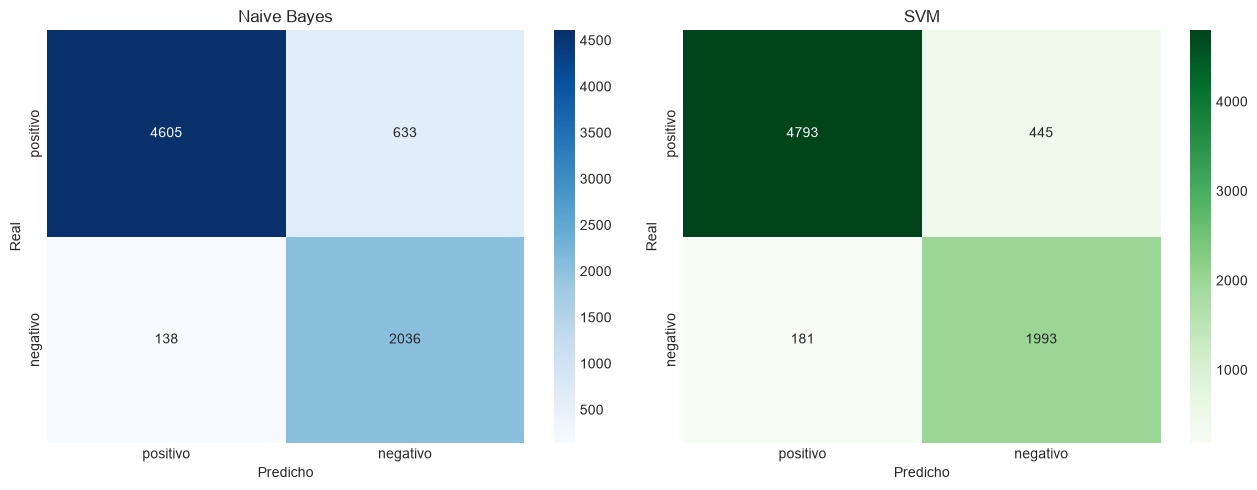

In [7]:
# Orden de las clases para la matriz
labels = ['positivo', 'negativo']

# 2 subplots, uno por modelo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusion de NB
cm_nb = confusion_matrix(y_test_txt, y_pred_nb, labels=labels)
# Heatmap con conteos
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_title('Naive Bayes')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Matriz de confusion de SVM
cm_svm = confusion_matrix(y_test_txt, y_pred_svm, labels=labels)
# Heatmap con conteos
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_title('SVM')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

# Ajusta y muestra
plt.tight_layout()
plt.show()

## Validacion cruzada de ambos


In [8]:
# CV 5 pliegues NB
cv_nb = cross_val_score(pipe_nb, X_text, y_text, cv=5, scoring='accuracy')
# CV 5 pliegues SVM
cv_svm = cross_val_score(pipe_svm, X_text, y_text, cv=5, scoring='accuracy')

# Promedio +/- desvio de NB
print(f'Naive Bayes CV Accuracy: {cv_nb.mean():.3f} +/- {cv_nb.std():.3f}')
# Promedio +/- desvio de SVM
print(f'SVM CV Accuracy:         {cv_svm.mean():.3f} +/- {cv_svm.std():.3f}')

Naive Bayes CV Accuracy: 0.898 +/- 0.002
SVM CV Accuracy:         0.918 +/- 0.002


## Terminos que delatan cada sentimiento

Extraer los terminos con mayor peso en cada clase, para validar que el modelo
aprendio marcadores de sentimiento coherentes con el negocio.

In [9]:
# Extrae los terminos mas decisivos por clase
def palabras_clave(pipeline, top_n=10):
# Acceso al vectorizador dentro del pipeline
    tfidf = pipeline.named_steps['tfidf']
# Acceso al clasificador
    clf = pipeline.named_steps['clf']
# Nombres de los terminos
    features = tfidf.get_feature_names_out()

# Ramas para modelos con coef_ (SVM lineal)
    if hasattr(clf, 'coef_'):
# SVM binario expone una sola fila de coef_ (positiva en una clase,
        # SVM binario expone una sola fila de coef_ (positiva en una clase,
# negativa en la otra).
        # negativa en la otra).
# Caso binario: una fila
        if clf.coef_.shape[0] == 1:
# Pesos de la clase 1
            pesos = clf.coef_[0]
# Top n positivos
            idx_pos = np.argsort(pesos)[-top_n:]
# Top n negativos
            idx_neg = np.argsort(pesos)[:top_n]
# Clase a la que corresponden los pesos positivos
            print(f'{clf.classes_[1]}: {', '.join(features[j] for j in idx_pos)}')
# Clase de los pesos negativos
            print(f'{clf.classes_[0]}: {', '.join(features[j] for j in idx_neg)}')
        else:
# Caso multiclase (si algun dia)
            for i, clase in enumerate(clf.classes_):
# Recorre clases
                idx = np.argsort(clf.coef_[i])[-top_n:]
# Top n por clase
                palabras = [features[j] for j in idx]
                print(f'{clase}: {', '.join(palabras)}')
# Rama para Naive Bayes (feature_log_prob_)
    elif hasattr(clf, 'feature_log_prob_'):
# Recorre clases
        for i, clase in enumerate(clf.classes_):
# Indices de mayor log-probabilidad
            idx = clf.feature_log_prob_[i].argsort()[-top_n:]
            palabras = [features[j] for j in idx]
            print(f'{clase}: {', '.join(palabras)}')

# Ejecuta con SVM
print('--- SVM: palabras clave ---')
palabras_clave(pipe_svm)
# Ejecuta con Naive Bayes
print('\n--- Naive Bayes: palabras clave ---')
palabras_clave(pipe_nb)

--- SVM: palabras clave ---
positivo: lind, proteg, benefíci, show, perfeit, ótim, rápid, ame, atenci, fácil
negativo: não, péss, pi, esquerd, falsific, incomplet, insatisfeit, urg, inferi, pess

--- Naive Bayes: palabras clave ---
negativo: micr, louç, mecan, lua, xper, vouch, matiz, mangu, maqui, mach
positivo: paralis, mut, muy, namor, otin, youtub, vlw, adoreiii, adquer, normal
